# Minería de Datos
## Taller: Preprocesamiento
## Datos del estudiante
- **Nombre:** Angel David Pineros Sierra
- **Asignatura:** Mineria de Datos
- **Tema:** Seleccion de caracteristicas basada en entropia
- **Fecha:** 11 De marzo de 2026

**Profesora:** Elizabeth León Guzmán

Este notebook contiene las actividades del taller de preprocesamiento. Cada sección incluye espacios para implementar los cálculos o experimentos en Python o documentar los resultados.

In [ ]:
import numpy as np
from pathlib import Path
import shutil
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np

## 1. Normalización
Dado el conjunto de datos:

X = {-5.0, 23.0, 17.6, 7.23, 1.11}

Realizar:
- Min-Max normalización en [0,1]
- Min-Max normalización en [-1,1]
- Normalización usando desviación estándar
- Escala decimal
- Comparar resultados

In [ ]:
X = np.array([-5.0, 23.0, 17.6, 7.23, 1.11])

### Min-Max [0,1]

In [2]:
x_min = np.min(X)
x_max = np.max(X)
x_norm_0_1 = (X - x_min) / (x_max - x_min)

print("Min-Max [0,1]")
print(f"Minimo: {x_min:.2f} | Maximo: {x_max:.2f}")
print(np.round(x_norm_0_1, 4))

Min-Max [0,1]
Minimo: -5.00 | Maximo: 23.00
[0.     1.     0.8071 0.4368 0.2182]


### Min-Max [-1,1]


In [3]:
x_norm_1_1 = 2 * x_norm_0_1 - 1

print("Min-Max [-1,1]")
print(np.round(x_norm_1_1, 4))

Min-Max [-1,1]
[-1.      1.      0.6143 -0.1264 -0.5636]


### Desviación estándar


In [4]:
x_mean = np.mean(X)
x_std = np.std(X)
x_norm_mean_dev = (X - x_mean) / x_std

print("Normalizacion por desviacion estandar")
print(f"Media: {x_mean:.4f} | Desviacion estandar: {x_std:.4f}")
print("Original:", np.round(X, 4))
print("Transformado:", np.round(x_norm_mean_dev, 4))

Normalizacion por desviacion estandar
Media: 8.7880 | Desviacion estandar: 10.3065
Original: [-5.   23.   17.6   7.23  1.11]
Transformado: [-1.3378  1.3789  0.855  -0.1512 -0.745 ]


### Escala decimal


In [5]:
max_abs = np.max(np.abs(X))
j = len(str(int(max_abs)))
x_norm_decimal = X / 10**j

print("Escala decimal")
print(f"Maximo valor absoluto: {max_abs:.2f} | j: {j}")
print(np.round(x_norm_decimal, 4))


Escala decimal
Maximo valor absoluto: 23.00 | j: 2
[-0.05    0.23    0.176   0.0723  0.0111]


### Comparación

| Método | Idea principal | Rango de salida | ¿Centrado en 0? | Sensibilidad a outliers | Observación |
|---|---|---|---|---|---|
| Min-Max [0,1] | Reescala usando mínimo y máximo | [0,1] | No | Alta | Útil cuando se necesita un rango fijo positivo. |
| Min-Max [-1,1] | Reescala usando mínimo y máximo y desplaza al intervalo [-1,1] | [-1,1] | Parcialmente, pero no necesariamente con media 0 | Alta | Conserva proporciones relativas, pero depende de valores extremos. |
| Desviación estándar | Centra en la media y escala por la desviación estándar | No fijo | Sí, aproximadamente | Alta | Útil para analizar qué tan lejos está cada valor del promedio. |
| Escala decimal | Divide entre una potencia de 10 según el mayor valor absoluto | Generalmente (-1,1) | No | Media | Es simple, pero no considera la distribución de los datos. |

## 2. Valores perdidos
### 2.1 Dataset:

| I1 | I2 | I3 | I4 |
|----|----|----|----|
|0|1|1|2|
|2|1|?|1|
|1|?|?|0|
|?|2|1|?|
|2|2|1|0|

- Dominio: {0,1,2}
- Calcular número de ejemplos artificiales si los valores faltantes se reemplazan con todos los posibles valores.
- Proponer otro método para imputación.

In [6]:
import itertools
import pandas as pd

data = [
    [0, 1, 1, 2],
    [2, 1, None, 1],
    [1, None, None, 0],
    [None, 2, 1, None],
    [2, 2, 1, 0],
]

df = pd.DataFrame(data, columns=["I1", "I2", "I3", "I4"])
dominio = [0, 1, 2]

ejemplos_artificiales = []

for _, fila in df.iterrows():
    columnas_faltantes = fila.index[fila.isna()]
    cantidad_faltantes = len(columnas_faltantes)

    if cantidad_faltantes == 0:
        continue

    for valores in itertools.product(dominio, repeat=cantidad_faltantes):
        nueva_fila = fila.copy()
        for columna, valor in zip(columnas_faltantes, valores):
            nueva_fila[columna] = valor
        ejemplos_artificiales.append(nueva_fila)

df_artificiales = pd.DataFrame(ejemplos_artificiales)

print("Numero de ejemplos artificiales:", len(df_artificiales))
df_artificiales


Numero de ejemplos artificiales: 21


,I1,I2,I3,I4
1,2.0,1.0,0.0,1.0
1,2.0,1.0,1.0,1.0
1,2.0,1.0,2.0,1.0
2,1.0,0.0,0.0,0.0
2,1.0,0.0,1.0,0.0
2,1.0,0.0,2.0,0.0
2,1.0,1.0,0.0,0.0
2,1.0,1.0,1.0,0.0
2,1.0,1.0,2.0,0.0
2,1.0,2.0,0.0,0.0


In [7]:
# Otro metodo de imputacion: reemplazar faltantes con la moda de cada atributo
df_imputado_moda = df.copy()

for columna in df_imputado_moda.columns:
    moda = df_imputado_moda[columna].mode()[0]
    df_imputado_moda[columna] = df_imputado_moda[columna].fillna(moda)

print("Dataset imputado con la moda:")
df_imputado_moda


Dataset imputado con la moda:


,I1,I2,I3,I4
0,0.0,1.0,1.0,2.0
1,2.0,1.0,1.0,1.0
2,1.0,1.0,1.0,0.0
3,2.0,2.0,1.0,0.0
4,2.0,2.0,1.0,0.0


 ### 2.2 Cargar el conjunto de datos de cancer que se encuentra en: (https://archive.ics.uci.edu/ml/datasets/breast+cancer+wisconsin+(original). Los valores perdidos están identificados con  '?'


*   Imprimir Numero de instancias, número de atributos, y nombre y número de valores perdidos por cada uno de los atributos. ¿Qué sucede con la variable 'Bare Nuclei'?
*   Remplazar los valore perdidos de la variable 'Bare Nuclei'con el valor de la media.
* Otro método de tratar valores perdido es eliminar los objetos que tienen valores perdidos. Borrar los objetos que tienen valores perdidos e imprimir el tamaño del nuevo conjunto de datos. ¿Cuál fue la proporción de ejemplos borrados?




In [8]:
%pip install ucimlrepo

In [9]:
from ucimlrepo import fetch_ucirepo

# Cargar dataset Breast Cancer Wisconsin (Original)
breast_cancer_wisconsin_original = fetch_ucirepo(id=15)

# Datos como DataFrames de pandas
X = breast_cancer_wisconsin_original.data.features
y = breast_cancer_wisconsin_original.data.targets

# Metadatos e informacion de variables
print(breast_cancer_wisconsin_original.metadata)
print(breast_cancer_wisconsin_original.variables)


{'uci_id': 15, 'name': 'Breast Cancer Wisconsin (Original)', 'repository_url': 'https://archive.ics.uci.edu/dataset/15/breast+cancer+wisconsin+original', 'data_url': 'https://archive.ics.uci.edu/static/public/15/data.csv', 'abstract': 'Original Wisconsin Breast Cancer Database', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 699, 'num_features': 9, 'feature_types': ['Integer'], 'demographics': [], 'target_col': ['Class'], 'index_col': ['Sample_code_number'], 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1990, 'last_updated': 'Sun Mar 10 2024', 'dataset_doi': '10.24432/C5HP4Z', 'creators': ['WIlliam Wolberg'], 'intro_paper': None, 'additional_info': {'summary': "Samples arrive periodically as Dr. Wolberg reports his clinical cases. The database therefore reflects this chronological grouping of the data. This grouping information appears immediately below, having been removed fro

In [10]:
# Unir atributos y clase para inspeccionar el dataset completo
df_cancer = X.copy()
df_cancer["Class"] = y.iloc[:, 0]

print("Numero de instancias:", df_cancer.shape[0])
print("Numero de atributos:", X.shape[1])

print("\nNombre y numero de valores perdidos por atributo:")
for columna in X.columns:
    if columna == "Bare_Nuclei":
        faltantes = X[columna].isna().sum() + X[columna].astype(str).eq("?").sum()
    else:
        faltantes = X[columna].isna().sum()
    print(f"{columna}: {faltantes}")

print("\nQue sucede con la variable 'Bare Nuclei'?")
print("Es la unica variable con valores perdidos; esos faltantes impiden tratarla directamente como numerica hasta imputarla o convertirla.")


Numero de instancias: 699
Numero de atributos: 9

Nombre y numero de valores perdidos por atributo:
Clump_thickness: 0
Uniformity_of_cell_size: 0
Uniformity_of_cell_shape: 0
Marginal_adhesion: 0
Single_epithelial_cell_size: 0
Bare_nuclei: 16
Bland_chromatin: 0
Normal_nucleoli: 0
Mitoses: 0

Que sucede con la variable 'Bare Nuclei'?
Es la unica variable con valores perdidos; esos faltantes impiden tratarla directamente como numerica hasta imputarla o convertirla.


In [11]:
# Reemplazar los valores perdidos de Bare_nuclei con la media
X_imputado_media = X.copy()

X_imputado_media["Bare_nuclei"] = pd.to_numeric(
    X_imputado_media["Bare_nuclei"], errors="coerce"
)

media_bare_nuclei = X_imputado_media["Bare_nuclei"].mean()
X_imputado_media["Bare_nuclei"] = X_imputado_media["Bare_nuclei"].fillna(media_bare_nuclei)

print("Media de Bare_nuclei:", round(media_bare_nuclei, 4))
print("Valores perdidos despues de imputar:", X_imputado_media["Bare_nuclei"].isna().sum())
X_imputado_media.head()


Media de Bare_nuclei: 3.5447
Valores perdidos despues de imputar: 0


,Clump_thickness,Uniformity_of_cell_size,Uniformity_of_cell_shape,Marginal_adhesion,Single_epithelial_cell_size,Bare_nuclei,Bland_chromatin,Normal_nucleoli,Mitoses
0,5,1,1,1,2,1.0,3,1,1
1,5,4,4,5,7,10.0,3,2,1
2,3,1,1,1,2,2.0,3,1,1
3,6,8,8,1,3,4.0,3,7,1
4,4,1,1,3,2,1.0,3,1,1


In [12]:
# Eliminar objetos con valores perdidos del dataset original
X_original = X.copy()
X_original["Bare_nuclei"] = pd.to_numeric(X_original["Bare_nuclei"], errors="coerce")

instancias_originales = X_original.shape[0]
X_sin_faltantes = X_original.dropna()
instancias_nuevas = X_sin_faltantes.shape[0]
proporcion_borrada = (instancias_originales - instancias_nuevas) / instancias_originales

print("Tamaño original del dataset:", instancias_originales)
print("Tamaño del nuevo dataset sin valores perdidos:", instancias_nuevas)
print("Proporcion de ejemplos borrados:", round(proporcion_borrada, 4))
X_sin_faltantes.head()


Tamaño original del dataset: 699
Tamaño del nuevo dataset sin valores perdidos: 683
Proporcion de ejemplos borrados: 0.0229


,Clump_thickness,Uniformity_of_cell_size,Uniformity_of_cell_shape,Marginal_adhesion,Single_epithelial_cell_size,Bare_nuclei,Bland_chromatin,Normal_nucleoli,Mitoses
0,5,1,1,1,2,1.0,3,1,1
1,5,4,4,5,7,10.0,3,2,1
2,3,1,1,1,2,2.0,3,1,1
3,6,8,8,1,3,4.0,3,7,1
4,4,1,1,3,2,1.0,3,1,1


## 3. Detección de Outliers
### 3.1 Vector: C = {3, 1, 0, 2, 7, 3, 6, 4, -2, 0, 0, 10, 15, 6}

- Calcular media
- Calcular desviación estándar
- Detectar outliers usando ±3σ y ±2σ

In [13]:
C = np.array([3, 1, 0, 2, 7, 3, 6, 4, -2, 0, 0, 10, 15, 6])

media = C.mean()
desviacion = C.std()

limite_inferior_2s = media - 2 * desviacion
limite_superior_2s = media + 2 * desviacion
outliers_2s = C[(C < limite_inferior_2s) | (C > limite_superior_2s)]

limite_inferior_3s = media - 3 * desviacion
limite_superior_3s = media + 3 * desviacion
outliers_3s = C[(C < limite_inferior_3s) | (C > limite_superior_3s)]

print("Media:", round(media, 4))
print("Desviacion estandar:", round(desviacion, 4))

print("\nLimites con ±2σ:")
print("Inferior:", round(limite_inferior_2s, 4))
print("Superior:", round(limite_superior_2s, 4))
print("Outliers con ±2σ:", outliers_2s.tolist())

print("\nLimites con ±3σ:")
print("Inferior:", round(limite_inferior_3s, 4))
print("Superior:", round(limite_superior_3s, 4))
print("Outliers con ±3σ:", outliers_3s.tolist())


Media: 3.9286
Desviacion estandar: 4.4153

Limites con ±2σ:
Inferior: -4.902
Superior: 12.7592
Outliers con ±2σ: [15]

Limites con ±3σ:
Inferior: -9.3173
Superior: 17.1745
Outliers con ±3σ: []


### 3.2 Para el conjunto de datos anterior

* Dibujar *boxplot*  para el conjunto de datos del ejercicio anterior (cancer)  
*   ¿Cuáles variables tienen valores
anormalmente altos?
*  Para eliminar outliers, computar  Z-score por cada atributo y remosver las instancias que contengan atributos con valores anormalmente al tos o con bajo Z-score (ejemplo, if Z > 3 or Z <= -3).



Variables con valores anormalmente altos (z > 3):
Single_epithelial_cell_size    31
Mitoses                        31
dtype: int64

Numero de instancias originales (sin faltantes): 683
Numero de instancias eliminadas por outliers: 51
Numero de instancias finales: 632


,Clump_thickness,Uniformity_of_cell_size,Uniformity_of_cell_shape,Marginal_adhesion,Single_epithelial_cell_size,Bare_nuclei,Bland_chromatin,Normal_nucleoli,Mitoses
0,5,1,1,1,2,1.0,3,1,1
1,5,4,4,5,7,10.0,3,2,1
2,3,1,1,1,2,2.0,3,1,1
3,6,8,8,1,3,4.0,3,7,1
4,4,1,1,3,2,1.0,3,1,1


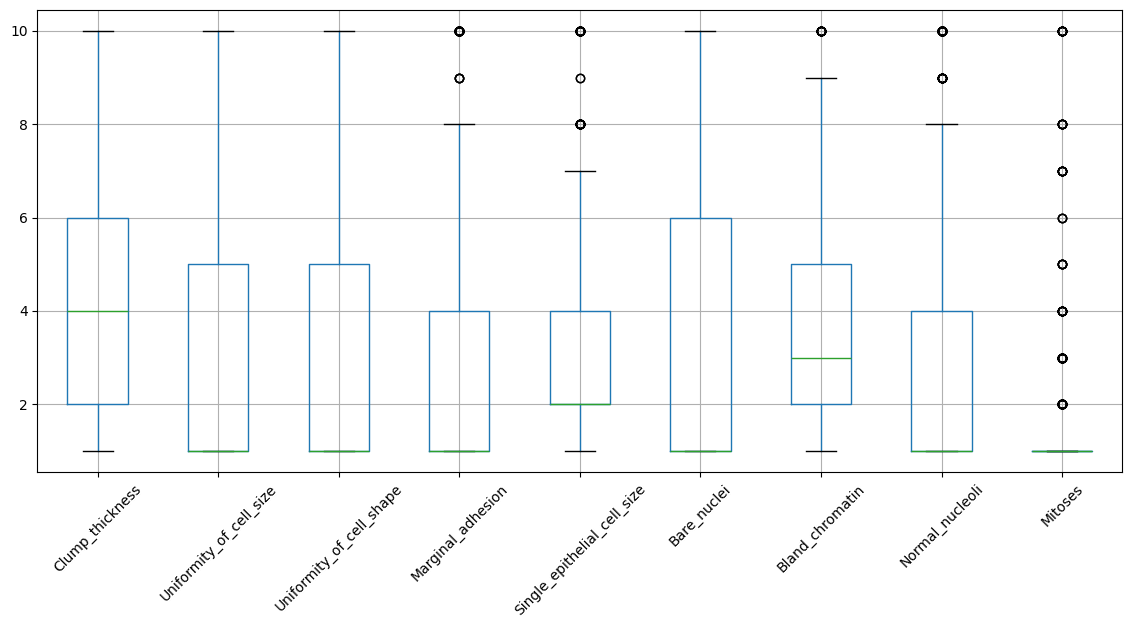

In [14]:
# Preparar el dataset de cancer para detectar outliers
X_cancer = X.copy()
X_cancer = X_cancer.apply(pd.to_numeric, errors="coerce")
X_cancer = X_cancer.dropna().copy()

# Dibujar boxplot por atributo
X_cancer.boxplot(figsize=(14, 6), rot=45)

# Calcular z-score por atributo
z_scores = (X_cancer - X_cancer.mean()) / X_cancer.std(ddof=0)

# Variables con valores anormalmente altos (z > 3)
valores_altos = (z_scores > 3).sum()
variables_altas = valores_altos[valores_altos > 0].sort_values(ascending=False)

print("Variables con valores anormalmente altos (z > 3):")
if variables_altas.empty:
    print("No se detectaron valores anormalmente altos con ese umbral.")
else:
    print(variables_altas)

# Eliminar instancias que tengan algun atributo con |z| > 3
mascara_outliers = (z_scores > 3) | (z_scores <= -3)
filas_con_outliers = mascara_outliers.any(axis=1)
X_cancer_sin_outliers = X_cancer.loc[~filas_con_outliers].copy()

print("\nNumero de instancias originales (sin faltantes):", X_cancer.shape[0])
print("Numero de instancias eliminadas por outliers:", filas_con_outliers.sum())
print("Numero de instancias finales:", X_cancer_sin_outliers.shape[0])

X_cancer_sin_outliers.head()


### 3.3 Para este conjunto de datos: X = [(1,2,0),(3,1,4),(2,1,5),(0,1,6),(2,4,3),(4,4,2),(5,2,1),(7,7,7),(0,0,0),(3,3,3)]

Describir el procedimiento de detección de outliers usando media y varianza.

In [15]:
X = np.array([
    [1, 2, 0],
    [3, 1, 4],
    [2, 1, 5],
    [0, 1, 6],
    [2, 4, 3],
    [4, 4, 2],
    [5, 2, 1],
    [7, 7, 7],
    [0, 0, 0],
    [3, 3, 3],
])

media = X.mean(axis=0)
varianza = X.var(axis=0)
desviacion = X.std(axis=0)
z_scores = (X - media) / desviacion

print("Media por dimension:", np.round(media, 4))
print("Varianza por dimension:", np.round(varianza, 4))

filas_outlier = (np.abs(z_scores) > 3).any(axis=1)
print("\nIndices detectados como outliers con |z| > 3:", np.where(filas_outlier)[0].tolist())


Media por dimension: [2.7 2.5 3.1]
Varianza por dimension: [4.41 3.85 5.29]

Indices detectados como outliers con |z| > 3: []


Procedimiento para detectar outliers usando media y varianza:
1. Calcular la media de cada dimension.
2. Calcular la varianza o la desviacion estandar de cada dimension.
3. Estandarizar cada valor con z-score: z = (x - media) / desviacion.
4. Marcar como outlier cualquier objeto que tenga al menos una dimension con |z| > 3.

## 5. Experimentos en Weka
- Cargar dataset **iris**

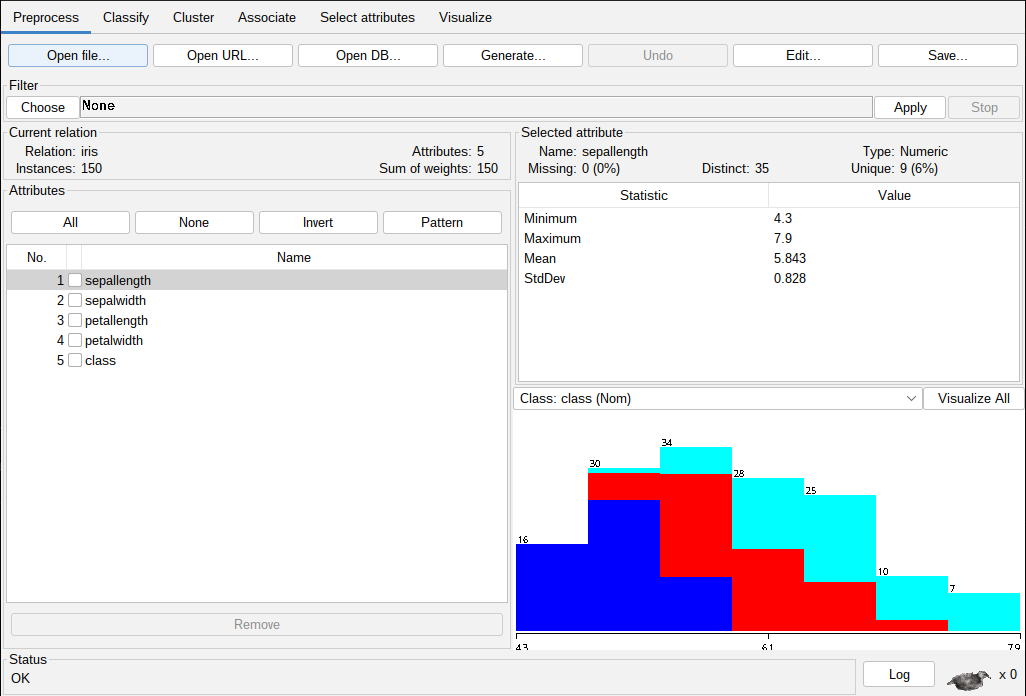

- Eliminar 15% de valores

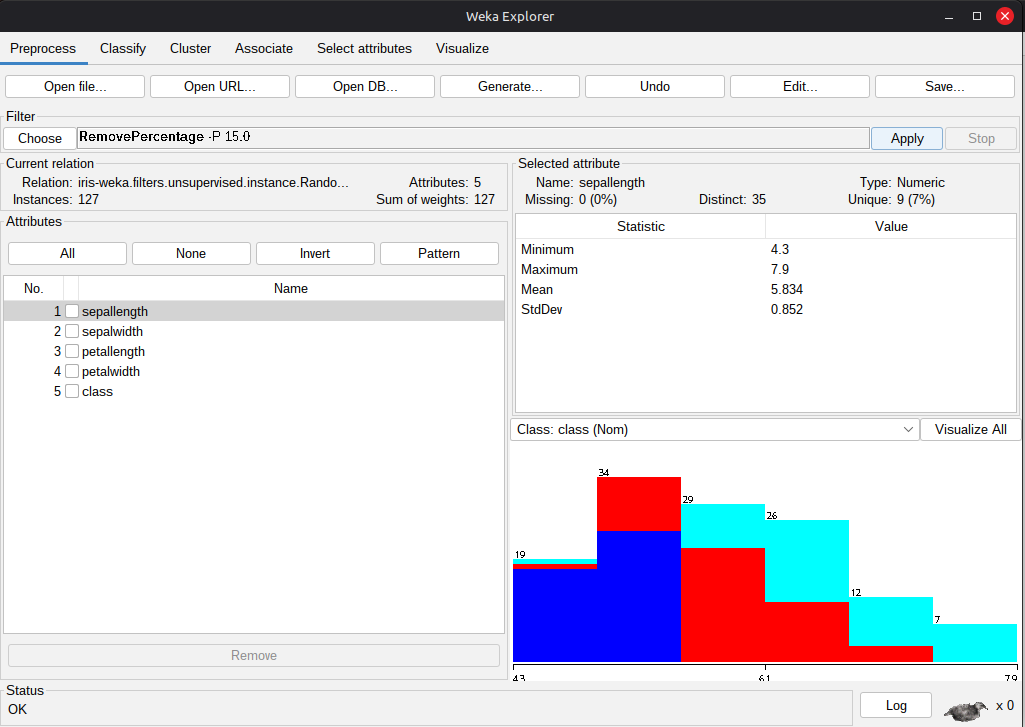

- Aplicar métodos de imputación
- Comparar resultados

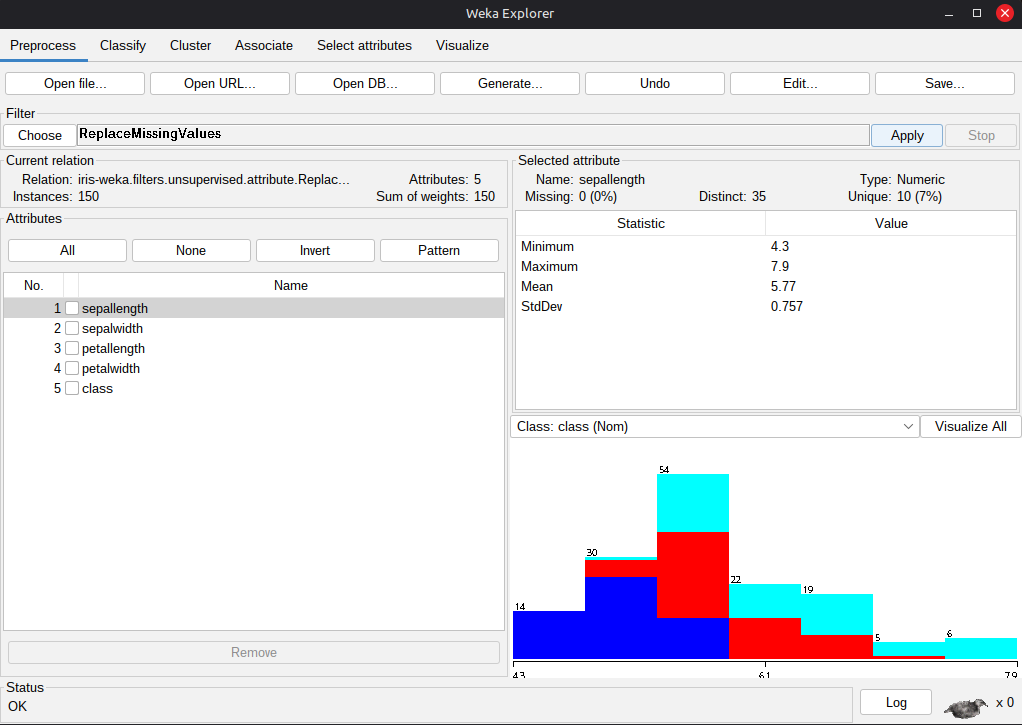

- Normalizar atributos

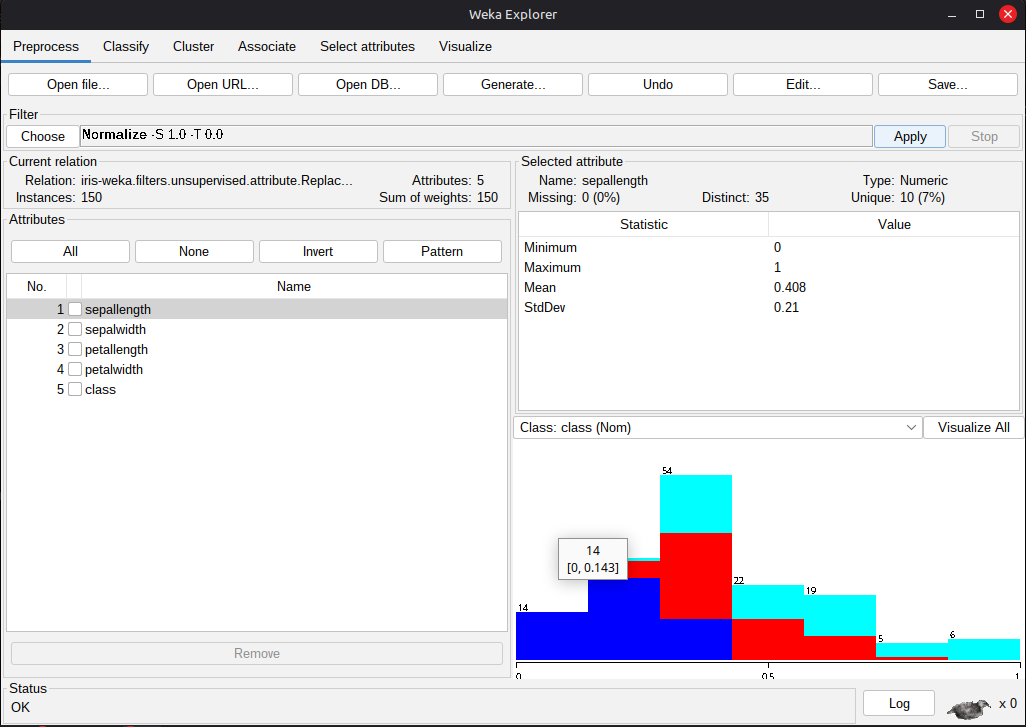


- Discretizar atributos

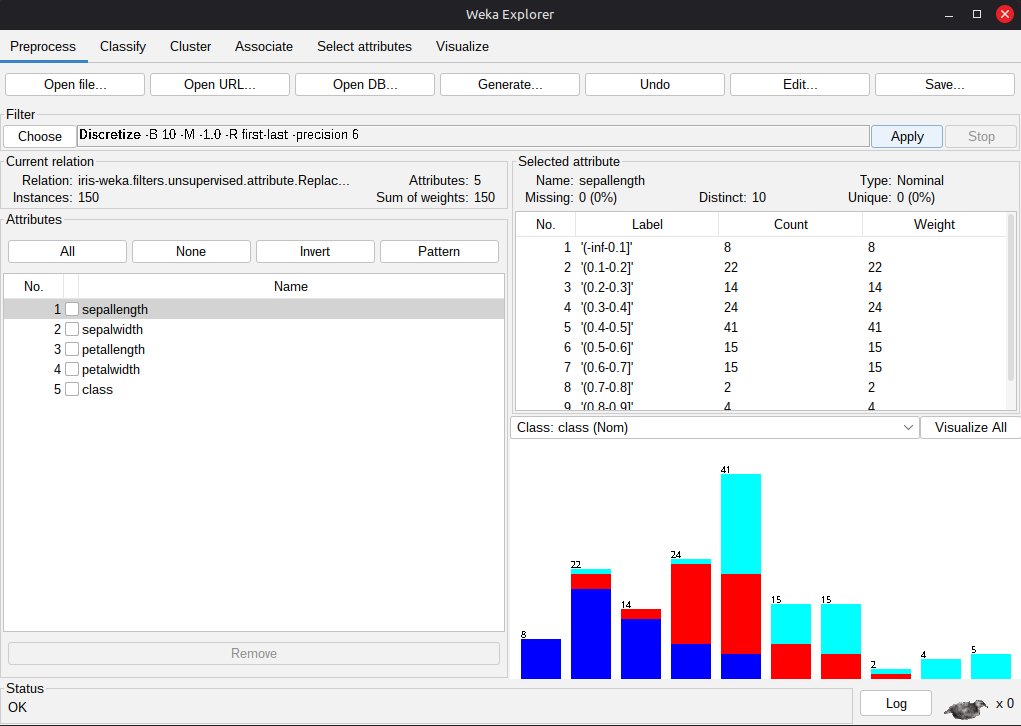

## 6. Reducción de valores mediante Binning

Dado el conjunto de datos:
|I1|I2|I3|
|--|--|--|
|1|5.9|3.4|
|2|2.1|6.2|
|1|1.6|2.8|
|2|6.8|5.8|
|1|3.1|3.1|
|1|8.3|4.1|
|2|2.4|5.0|

Realizar reducción de valores basado en la técnica de ***BIN*** con el mejor corte para lo siguiente (mostrar pasos):

- Dimensión $I2$ usando la media como representantes de 2 BINS.
- Dimensión $I3$ usando el límite más cercano como representante de 2 BINS.


In [23]:
df_binning = pd.DataFrame({
    "I1": [1, 2, 1, 2, 1, 1, 2],
    "I2": [5.9, 2.1, 1.6, 6.8, 3.1, 8.3, 2.4],
    "I3": [3.4, 6.2, 2.8, 5.8, 3.1, 4.1, 5.0],
})

def error_media(bin_):
    media = np.mean(bin_)
    error = sum(abs(x - media) for x in bin_)
    return media, error

def error_limite_cercano(bin_):
    limite_inferior = bin_[0]
    limite_superior = bin_[-1]
    error = sum(min(abs(x - limite_inferior), abs(x - limite_superior)) for x in bin_)
    return (limite_inferior, limite_superior), error

def mejor_corte(valores_ordenados, tipo="media"):
    n = len(valores_ordenados)
    cortes_candidatos = [n // 2, n - (n // 2)]
    cortes_candidatos = sorted(set(c for c in cortes_candidatos if 0 < c < n))

    mejor = None
    evaluaciones = []
    for corte in cortes_candidatos:
        bin_1 = valores_ordenados[:corte]
        bin_2 = valores_ordenados[corte:]

        if tipo == "media":
            rep_1, err_1 = error_media(bin_1)
            rep_2, err_2 = error_media(bin_2)
        else:
            rep_1, err_1 = error_limite_cercano(bin_1)
            rep_2, err_2 = error_limite_cercano(bin_2)

        error_total = err_1 + err_2
        candidato = {
            "corte": corte,
            "bin_1": bin_1,
            "bin_2": bin_2,
            "rep_1": rep_1,
            "rep_2": rep_2,
            "error_total": error_total,
        }
        evaluaciones.append(candidato)

        if mejor is None or candidato["error_total"] < mejor["error_total"]:
            mejor = candidato

    return mejor, evaluaciones

def limite_mas_cercano(valor, limite_inferior, limite_superior):
    if abs(valor - limite_inferior) <= abs(valor - limite_superior):
        return limite_inferior
    return limite_superior

i2_ordenado = sorted(df_binning["I2"])
mejor_i2, evaluaciones_i2 = mejor_corte(i2_ordenado, tipo="media")
corte_i2 = (mejor_i2["bin_1"][-1] + mejor_i2["bin_2"][0]) / 2

df_binning["I2_binning"] = np.where(
    df_binning["I2"] <= corte_i2,
    mejor_i2["rep_1"],
    mejor_i2["rep_2"],
)

print("I2 ordenado:", i2_ordenado)
print("Cortes candidatos y error para I2:")
for evaluacion in evaluaciones_i2:
    print(
        f"  corte={evaluacion['corte']}: {evaluacion['bin_1']} | {evaluacion['bin_2']} -> ER={round(evaluacion['error_total'], 4)}"
    )
print("Mejor corte I2 despues de minimizar ER:", mejor_i2["corte"])
print("BIN 1 I2:", mejor_i2["bin_1"], "-> representante (media):", round(mejor_i2["rep_1"], 4))
print("BIN 2 I2:", mejor_i2["bin_2"], "-> representante (media):", round(mejor_i2["rep_2"], 4))
print("Error total I2:", round(mejor_i2["error_total"], 4))
print("Corte numerico I2:", round(corte_i2, 4))

i3_ordenado = sorted(df_binning["I3"])
mejor_i3, evaluaciones_i3 = mejor_corte(i3_ordenado, tipo="limite")
corte_i3 = (mejor_i3["bin_1"][-1] + mejor_i3["bin_2"][0]) / 2

df_binning["I3_binning"] = df_binning["I3"].apply(
    lambda x: limite_mas_cercano(x, *mejor_i3["rep_1"])
    if x <= corte_i3 else limite_mas_cercano(x, *mejor_i3["rep_2"])
)

print("\nI3 ordenado:", i3_ordenado)
print("Cortes candidatos y error para I3:")
for evaluacion in evaluaciones_i3:
    print(
        f"  corte={evaluacion['corte']}: {evaluacion['bin_1']} | {evaluacion['bin_2']} -> ER={round(evaluacion['error_total'], 4)}"
    )
print("Mejor corte I3 despues de minimizar ER:", mejor_i3["corte"])
print("BIN 1 I3:", mejor_i3["bin_1"], "-> limites:", mejor_i3["rep_1"])
print("BIN 2 I3:", mejor_i3["bin_2"], "-> limites:", mejor_i3["rep_2"])
print("Error total I3:", round(mejor_i3["error_total"], 4))
print("Corte numerico I3:", round(corte_i3, 4))

print("\nTabla final con binning optimizado:")
df_binning[["I1", "I2", "I2_binning", "I3", "I3_binning"]]


I2 ordenado: [1.6, 2.1, 2.4, 3.1, 5.9, 6.8, 8.3]
Cortes candidatos y error para I2:
  corte=3: [1.6, 2.1, 2.4] | [3.1, 5.9, 6.8, 8.3] -> ER=6.9667
  corte=4: [1.6, 2.1, 2.4, 3.1] | [5.9, 6.8, 8.3] -> ER=4.4
Mejor corte I2 despues de minimizar ER: 4
BIN 1 I2: [1.6, 2.1, 2.4, 3.1] -> representante (media): 2.3
BIN 2 I2: [5.9, 6.8, 8.3] -> representante (media): 7.0
Error total I2: 4.4
Corte numerico I2: 4.5

I3 ordenado: [2.8, 3.1, 3.4, 4.1, 5.0, 5.8, 6.2]
Cortes candidatos y error para I3:
  corte=3: [2.8, 3.1, 3.4] | [4.1, 5.0, 5.8, 6.2] -> ER=1.6
  corte=4: [2.8, 3.1, 3.4, 4.1] | [5.0, 5.8, 6.2] -> ER=1.3
Mejor corte I3 despues de minimizar ER: 4
BIN 1 I3: [2.8, 3.1, 3.4, 4.1] -> limites: (2.8, 4.1)
BIN 2 I3: [5.0, 5.8, 6.2] -> limites: (5.0, 6.2)
Error total I3: 1.3
Corte numerico I3: 4.55

Tabla final con binning optimizado:


,I1,I2,I2_binning,I3,I3_binning
0,1,5.9,7.0,3.4,2.8
1,2,2.1,2.3,6.2,6.2
2,1,1.6,2.3,2.8,2.8
3,2,6.8,7.0,5.8,6.2
4,1,3.1,2.3,3.1,2.8
5,1,8.3,7.0,4.1,4.1
6,2,2.4,2.3,5.0,5.0


## 8. Dataset Adult


Al conjunto de datos Adult del repositorio de Machine Learning:

- Convertir todos los atributos numéricos a categóricos utilizando dos estrategias diferentes.
- Transformar el conjunto de datos de manera que todos los atributos sean numéricos.

In [29]:
from ucimlrepo import fetch_ucirepo

# Cargar dataset Adult desde UCI
adult = fetch_ucirepo(id=2)
X_adult = adult.data.features.copy()
y_adult = adult.data.targets.copy()

print("Forma de X:", X_adult.shape)
print("Columnas:", X_adult.columns.tolist())

# Identificar atributos numericos
numeric_cols = X_adult.select_dtypes(include=["number"]).columns.tolist()
print("\nAtributos numericos:", numeric_cols)

# Estrategia 1: discretizacion por amplitud igual
adult_bins_amplitud = X_adult.copy()
for col in numeric_cols:
    adult_bins_amplitud[col] = pd.cut(
        adult_bins_amplitud[col], bins=3, labels=["bajo", "medio", "alto"]
    )

# Estrategia 2: discretizacion por frecuencia igual
labels_base = ["bajo", "medio", "alto"]
adult_bins_frecuencia = X_adult.copy()
for col in numeric_cols:
    _, bins = pd.qcut(adult_bins_frecuencia[col], q=3, retbins=True, duplicates="drop")
    n_bins = len(bins) - 1
    labels = labels_base[:n_bins]
    adult_bins_frecuencia[col] = pd.qcut(
        adult_bins_frecuencia[col], q=3, labels=labels, duplicates="drop"
    )

print("\nDiscretizacion por amplitud igual:")
display(adult_bins_amplitud.head())

print("Discretizacion por frecuencia igual:")
display(adult_bins_frecuencia.head())

# Reemplazar '?' por NaN para limpiar categorias con faltantes
X_adult_limpio = X_adult.replace("?", np.nan).copy()

# Imputacion simple antes de codificar
for col in X_adult_limpio.columns:
    if X_adult_limpio[col].dtype == "object":
        X_adult_limpio[col] = X_adult_limpio[col].fillna(X_adult_limpio[col].mode()[0])
    else:
        X_adult_limpio[col] = X_adult_limpio[col].fillna(X_adult_limpio[col].median())

# Transformar todo el conjunto a numerico con one-hot encoding
X_adult_numerico = pd.get_dummies(X_adult_limpio, drop_first=False)

print("Forma transformada a numerico:", X_adult_numerico.shape)
X_adult_numerico.head()


Forma de X: (48842, 14)
Columnas: ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country']

Atributos numericos: ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

Discretizacion por amplitud igual:


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,bajo,State-gov,bajo,Bachelors,alto,Never-married,Adm-clerical,Not-in-family,White,Male,bajo,bajo,medio,United-States
1,medio,Self-emp-not-inc,bajo,Bachelors,alto,Married-civ-spouse,Exec-managerial,Husband,White,Male,bajo,bajo,bajo,United-States
2,bajo,Private,bajo,HS-grad,medio,Divorced,Handlers-cleaners,Not-in-family,White,Male,bajo,bajo,medio,United-States
3,medio,Private,bajo,11th,medio,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,bajo,bajo,medio,United-States
4,bajo,Private,bajo,Bachelors,alto,Married-civ-spouse,Prof-specialty,Wife,Black,Female,bajo,bajo,medio,Cuba


Discretizacion por frecuencia igual:


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,medio,State-gov,bajo,Bachelors,alto,Never-married,Adm-clerical,Not-in-family,White,Male,bajo,bajo,bajo,United-States
1,alto,Self-emp-not-inc,bajo,Bachelors,alto,Married-civ-spouse,Exec-managerial,Husband,White,Male,bajo,bajo,bajo,United-States
2,medio,Private,alto,HS-grad,bajo,Divorced,Handlers-cleaners,Not-in-family,White,Male,bajo,bajo,bajo,United-States
3,alto,Private,alto,11th,bajo,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,bajo,bajo,bajo,United-States
4,bajo,Private,alto,Bachelors,alto,Married-civ-spouse,Prof-specialty,Wife,Black,Female,bajo,bajo,bajo,Cuba


Forma transformada a numerico: (48842, 105)


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,workclass_Private,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
0,39,77516,13,2174,0,40,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,50,83311,13,0,0,13,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,38,215646,9,0,0,40,False,False,False,True,...,False,False,False,False,False,False,False,True,False,False
3,53,234721,7,0,0,40,False,False,False,True,...,False,False,False,False,False,False,False,True,False,False
4,28,338409,13,0,0,40,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False


## 9. Ranking de dimensiones (media y varianza)

Dado el siguiente conjunto de datos con tres dimensiones de entrada y una dimensión de clase:

|I1|I2|I3|C|
|--|--|--|--|
|2.5 | 1.6 | 5.9 | 0 |
|2.5 | 1.6 | 5.9 | 0 |
|7.2 | 4.3 | 2.1 | 1 |
|3.4 | 5.8 | 1.6 | 1 |
|5.6 | 3.6 | 6.8 | 0 |
|4.8 | 7.2 | 3.1 | 1 |
|8.1 | 4.9 | 8.3 | 0 |
|6.3 | 4.8 | 2.4 | 1 |

Realizar el ranking de las dimensiones mediante comparación de medias y varianzas.

In [30]:
df_rank = pd.DataFrame({
    "I1": [2.5, 2.5, 7.2, 3.4, 5.6, 4.8, 8.1, 6.3],
    "I2": [1.6, 1.6, 4.3, 5.8, 3.6, 7.2, 4.9, 4.8],
    "I3": [5.9, 5.9, 2.1, 1.6, 6.8, 3.1, 8.3, 2.4],
    "C":  [0, 0, 1, 1, 0, 1, 0, 1],
})

grupo_0 = df_rank[df_rank["C"] == 0]
grupo_1 = df_rank[df_rank["C"] == 1]

resumen = []
for columna in ["I1", "I2", "I3"]:
    media_0 = grupo_0[columna].mean()
    media_1 = grupo_1[columna].mean()
    var_0 = grupo_0[columna].var(ddof=0)
    var_1 = grupo_1[columna].var(ddof=0)
    fisher_score = ((media_0 - media_1) ** 2) / (var_0 + var_1)

    resumen.append({
        "dimension": columna,
        "media_clase_0": media_0,
        "media_clase_1": media_1,
        "varianza_clase_0": var_0,
        "varianza_clase_1": var_1,
        "fisher_score": fisher_score,
    })

resumen_dimensiones = pd.DataFrame(resumen).sort_values(
    by="fisher_score", ascending=False
).reset_index(drop=True)

ranking_dimensiones = " > ".join(resumen_dimensiones["dimension"].tolist())

print("Dataset:")
display(df_rank)

print("Resumen por dimension:")
display(resumen_dimensiones.round(4))

print("Ranking final:", ranking_dimensiones)


Dataset:


,I1,I2,I3,C
0,2.5,1.6,5.9,0
1,2.5,1.6,5.9,0
2,7.2,4.3,2.1,1
3,3.4,5.8,1.6,1
4,5.6,3.6,6.8,0
5,4.8,7.2,3.1,1
6,8.1,4.9,8.3,0
7,6.3,4.8,2.4,1


Resumen por dimension:


,dimension,media_clase_0,media_clase_1,varianza_clase_0,varianza_clase_1,fisher_score
0,I3,6.725,2.300,0.9619,0.2950,15.5788
1,I2,2.925,5.525,1.9669,1.2269,2.1166
2,I1,4.675,5.425,5.5119,2.1019,0.0739


Ranking final: I3 > I2 > I1


## 10. Selección de características usando entropía

Dado el conjunto de datos:

|X1|X2|X3|X4|
|--|--|--|--|
|2.7 | 3.4 | 1 | A |
|3.1 | 6.2 | 2 | A |
|4.5 | 2.8 | 1 | B |
|5.3 | 5.8 | 2 | B |
|6.6 | 3.1 | 1 | A |
|5.0 | 4.1 | 2 | B |

Aplicar el método de selección de características basado en entropía para reducir una dimensión (mostrar pasos).

In [31]:
df_entropy = pd.DataFrame({
    "X1": [2.7, 3.1, 4.5, 5.3, 6.6, 5.0],
    "X2": [3.4, 6.2, 2.8, 5.8, 3.1, 4.1],
    "X3": [1, 2, 1, 2, 1, 2],
    "X4": ["A", "A", "B", "B", "A", "B"],
})

def entropy_term(s, base=2):
    if s == 0 or s == 1:
        return 0.0
    return -(s * (np.log(s) / np.log(base)) + (1 - s) * (np.log(1 - s) / np.log(base)))

def similarity_matrix_from_columns(dataframe, columns):
    num_rows = dataframe.shape[0]
    matrix = np.zeros((num_rows, num_rows))

    for i in range(num_rows):
        for j in range(num_rows):
            row1 = dataframe.iloc[i][columns]
            row2 = dataframe.iloc[j][columns]
            matches = (row1 == row2).sum()
            matrix[i, j] = matches / len(columns)

    return matrix

def dataset_entropy(dataframe, columns=None, base=2):
    if columns is None:
        columns = list(dataframe.columns)

    similarity_matrix = similarity_matrix_from_columns(dataframe, columns)
    total_entropy = 0.0
    num_rows = similarity_matrix.shape[0]

    for i in range(num_rows - 1):
        for j in range(i + 1, num_rows):
            total_entropy += entropy_term(similarity_matrix[i, j], base=base)

    return total_entropy

def entropy_feature_ranking(dataframe, base=2, atol=1e-12):
    current_columns = list(dataframe.columns)
    ranking = []
    iteration_tables = []
    iteration = 1

    while len(current_columns) > 1:
        current_entropy = dataset_entropy(dataframe, current_columns, base=base)
        candidate_rows = []

        for column in current_columns:
            reduced_columns = [col for col in current_columns if col != column]
            reduced_entropy = dataset_entropy(dataframe, reduced_columns, base=base)
            delta_entropy = current_entropy - reduced_entropy

            candidate_rows.append({
                "iteracion": iteration,
                "columna_removida_candidata": column,
                "entropia_actual": current_entropy,
                "entropia_sin_columna": reduced_entropy,
                "delta_entropia": delta_entropy,
            })

        min_delta = min(row["delta_entropia"] for row in candidate_rows)
        tied_columns = [
            row["columna_removida_candidata"]
            for row in candidate_rows
            if np.isclose(row["delta_entropia"], min_delta, atol=atol, rtol=0)
        ]

        for row in candidate_rows:
            row["empate_minimo"] = row["columna_removida_candidata"] in tied_columns

        all_equal_deltas = all(
            np.isclose(row["delta_entropia"], candidate_rows[0]["delta_entropia"], atol=atol, rtol=0)
            for row in candidate_rows
        )

        if all_equal_deltas:
            iteration_tables.append({
                "iteracion": iteration,
                "tabla": pd.DataFrame(candidate_rows),
                "entropia_actual": current_entropy,
                "empatadas": tied_columns,
                "columna_eliminada": None,
                "columnas_restantes": current_columns.copy(),
                "detener_por_deltas_iguales": True,
                "mensaje": "No se elimina ninguna variable porque todos los deltas son iguales."
            })

            return {
                "ranking_eliminacion": ranking,
                "columna_final": None,
                "columnas_restantes": current_columns,
                "iteraciones": iteration_tables,
                "detenido_por_deltas_iguales": True,
            }

        selected_column = tied_columns[0]
        current_columns.remove(selected_column)
        ranking.append(selected_column)

        iteration_tables.append({
            "iteracion": iteration,
            "tabla": pd.DataFrame(candidate_rows),
            "entropia_actual": current_entropy,
            "empatadas": tied_columns,
            "columna_eliminada": selected_column,
            "columnas_restantes": current_columns.copy(),
            "detener_por_deltas_iguales": False,
        })

        iteration += 1

    return {
        "ranking_eliminacion": ranking,
        "columna_final": current_columns[0],
        "columnas_restantes": current_columns,
        "iteraciones": iteration_tables,
        "detenido_por_deltas_iguales": False,
    }

log_base = 10
ranking_result = entropy_feature_ranking(df_entropy, base=log_base)

print("Dataset original:")
display(df_entropy)

print("Base del logaritmo =", log_base)

for iteration_result in ranking_result["iteraciones"]:
    print(f"\nIteracion {iteration_result['iteracion']}:")
    display(iteration_result["tabla"].round(4))

    if iteration_result["detener_por_deltas_iguales"]:
        print(iteration_result["mensaje"])
        print("Columnas restantes:", iteration_result["columnas_restantes"])
        break

    if len(iteration_result["empatadas"]) > 1:
        print("Empate en la menor diferencia de entropia:", iteration_result["empatadas"])
        print("Se elimina la primera por el orden actual de columnas.")
    else:
        print("Mejor candidata a eliminar:", iteration_result["empatadas"][0])

    print("Columna eliminada:", iteration_result["columna_eliminada"])
    print("Columnas restantes:", iteration_result["columnas_restantes"])

print("\nRanking completo de eliminacion:", ranking_result["ranking_eliminacion"])

if ranking_result["detenido_por_deltas_iguales"]:
    print("El proceso se detuvo porque todos los deltas de la ultima iteracion fueron iguales.")
    print("No se elimina ninguna variable adicional en ese punto.")
    print("Columnas restantes:", ranking_result["columnas_restantes"])
else:
    print("Caracteristica final mas relevante:", ranking_result["columna_final"])


Dataset original:


,X1,X2,X3,X4
0,2.7,3.4,1,A
1,3.1,6.2,2,A
2,4.5,2.8,1,B
3,5.3,5.8,2,B
4,6.6,3.1,1,A
5,5.0,4.1,2,B


Base del logaritmo = 10

Iteracion 1:


,iteracion,columna_removida_candidata,entropia_actual,entropia_sin_columna,delta_entropia,empate_minimo
0,1,X1,2.5558,2.7643,-0.2085,True
1,1,X2,2.5558,2.7643,-0.2085,True
2,1,X3,2.5558,1.6586,0.8972,False
3,1,X4,2.5558,1.6586,0.8972,False


Empate en la menor diferencia de entropia: ['X1', 'X2']
Se elimina la primera por el orden actual de columnas.
Columna eliminada: X1
Columnas restantes: ['X2', 'X3', 'X4']

Iteracion 2:


,iteracion,columna_removida_candidata,entropia_actual,entropia_sin_columna,delta_entropia,empate_minimo
0,2,X2,2.7643,2.4082,0.3561,True
1,2,X3,2.7643,1.8062,0.9582,False
2,2,X4,2.7643,1.8062,0.9582,False


Mejor candidata a eliminar: X2
Columna eliminada: X2
Columnas restantes: ['X3', 'X4']

Iteracion 3:


,iteracion,columna_removida_candidata,entropia_actual,entropia_sin_columna,delta_entropia,empate_minimo
0,3,X3,2.4082,0.0,2.4082,True
1,3,X4,2.4082,0.0,2.4082,True


No se elimina ninguna variable porque todos los deltas son iguales.
Columnas restantes: ['X3', 'X4']

Ranking completo de eliminacion: ['X1', 'X2']
El proceso se detuvo porque todos los deltas de la ultima iteracion fueron iguales.
No se elimina ninguna variable adicional en ese punto.
Columnas restantes: ['X3', 'X4']


## 11. PCA (Principal Component Analysis)
El análisis de componentes principales (ACP) es un método clásico para reducir el número de atributos en los datos mediante la proyección de estos desde su espacio original de alta dimensión a un espacio de menor dimensión. Los nuevos atributos (también conocidos como componentes)  tienen las siguientes propiedades:




*   (1) son combinaciones lineales de los atributos originales,
*   (2) son ortogonales (perpendiculares) entre sí y
*   (3) capturan la máxima variación en los datos.

El siguiente ejemplo ilustra la aplicación de PCA a un conjunto de datos de imágenes. Hay 16 archivos RGB, cada uno con un tamaño de 111 x 111 píxeles. El código de ejemplo a continuación leerá cada archivo de imagen y convertirá la imagen RGB en una matriz de 111 x 111 x 3 = 36963 valores de características. Esto creará una matriz de datos de 16 x 36963. (ejemplo tomado de tutorial del libro de  "Introduction to Data Mining"


In [ ]:
base_dir = Path('/content')
base_dir.mkdir(exist_ok=True)
archive_path = base_dir / 'pics.zip'

extract_dir = Path('/content/extracted')
extract_dir.mkdir(exist_ok=True)

try:
    shutil.unpack_archive(str(archive_path), str(extract_dir))
except (shutil.ReadError, ValueError):
    pass

# Buscar la carpeta que contiene Picture1.jpg ... Picture16.jpg
image_dir = None
for candidate in [extract_dir, base_dir]:
    matches = list(candidate.rglob('Picture1.jpg'))
    if matches:
        image_dir = matches[0].parent
        break

if image_dir is None:
    raise FileNotFoundError(
        'No se encontraron las imagenes Picture*.jpg despues de la descarga.'
    )

numImages = 16
fig = plt.figure(figsize=(7, 7))
imgData = np.zeros(shape=(numImages, 36963))

for i in range(1, numImages + 1):
    filename = image_dir / f'Picture{i}.jpg'
    img = mpimg.imread(filename)
    ax = fig.add_subplot(4, 4, i)
    plt.imshow(img)
    plt.axis('off')
    ax.set_title(str(i))
    imgData[i - 1] = img.flatten()

print('Directorio de imagenes usado:', image_dir)

FileURLRetrievalError: Failed to retrieve file url:

	Cannot retrieve the public link of the file. You may need to change
	the permission to 'Anyone with the link', or have had many accesses.
	Check FAQ in https://github.com/wkentaro/gdown?tab=readme-ov-file#faq.

You may still be able to access the file from the browser:

	https://drive.google.com/uc?id=15XnP0aiZ-C6gP1mJnW9DZtCAQyWAZQNl

but Gdown can't. Please check connections and permissions.

Usando PCA, la matrix de datos es proyectada a 2 componentes.

In [ ]:
numComponents = 2
pca = PCA(n_components=numComponents)
pca.fit(imgData)

projected = pca.transform(imgData)
projected = pd.DataFrame(projected,columns=['pc1','pc2'],index=range(1,numImages+1))
projected['food'] = ['burger', 'burger','burger','burger','drink','drink','drink','drink',
                      'pasta', 'pasta', 'pasta', 'pasta', 'chicken', 'chicken', 'chicken', 'chicken']
projected

/usr/local/lib/python3.12/dist-packages/sklearn/decomposition/_pca.py:789: RuntimeWarning: invalid value encountered in divide
  self.explained_variance_ratio_ = self.explained_variance_ / total_var


,pc1,pc2,food
1,0.0,0.0,burger
2,0.0,0.0,burger
3,0.0,0.0,burger
4,0.0,0.0,burger
5,0.0,0.0,drink
6,0.0,0.0,drink
7,0.0,0.0,drink
8,0.0,0.0,drink
9,0.0,0.0,pasta
10,0.0,0.0,pasta


Finalmente, Dibujamos  scatter plot para ver los valores proyectados. Observe que las imágenes de hamburguesas, bebidas y pasta son proyectadas en la misma región. Sin embargo, Las imagenes de pollo frito es díficil de discriminar.

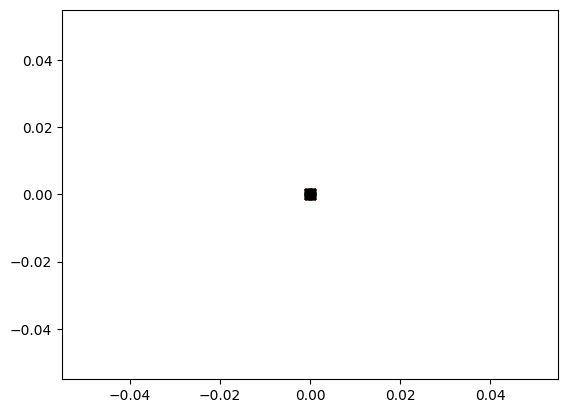

In [ ]:
colors = {'burger':'b', 'drink':'r', 'pasta':'g', 'chicken':'k'}
markerTypes = {'burger':'+', 'drink':'x', 'pasta':'o', 'chicken':'s'}

for foodType in markerTypes:
    d = projected[projected['food']==foodType]
    plt.scatter(d['pc1'],d['pc2'],c=colors[foodType],s=60,marker=markerTypes[foodType])

Escoger un conjunto de datos del repositorio de Machine Learning que tenga varias dimensiones numéricas y aplicar ***PCA***. Describir el nuevo conjunto de datos.

### Dataset elegido: Student Performance

Se utilizara el dataset **Student Performance** del repositorio UCI, importado con `ucimlrepo` usando `fetch_ucirepo(id=320)`. Este conjunto contiene variables academicas y demograficas relacionadas con el rendimiento de estudiantes.

Para aplicar **PCA** en este punto se tomaran solo las columnas numericas de `X`, ya que PCA opera sobre variables cuantitativas. Luego, esas variables se escalaran y se proyectaran en dos nuevos atributos: `PC1` y `PC2`.


In [53]:
from ucimlrepo import fetch_ucirepo

student_performance = fetch_ucirepo(id=320)

X = student_performance.data.features
y = student_performance.data.targets

print('Metadata del dataset:')
print(student_performance.metadata)
print('Informacion de variables:')
print(student_performance.variables)

numeric_cols = X.select_dtypes(include=['number']).columns.tolist()

print('Forma de X:', X.shape)
print('Cantidad de atributos numericos:', len(numeric_cols))
print('Columnas numericas:', numeric_cols)
display(X.head())


Metadata del dataset:
{'uci_id': 320, 'name': 'Student Performance', 'repository_url': 'https://archive.ics.uci.edu/dataset/320/student+performance', 'data_url': 'https://archive.ics.uci.edu/static/public/320/data.csv', 'abstract': 'Predict student performance in secondary education (high school). ', 'area': 'Social Science', 'tasks': ['Classification', 'Regression'], 'characteristics': ['Multivariate'], 'num_instances': 649, 'num_features': 30, 'feature_types': ['Integer'], 'demographics': ['Sex', 'Age', 'Other', 'Education Level', 'Occupation'], 'target_col': ['G1', 'G2', 'G3'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2008, 'last_updated': 'Fri Jan 05 2024', 'dataset_doi': '10.24432/C5TG7T', 'creators': ['Paulo Cortez'], 'intro_paper': {'ID': 360, 'type': 'NATIVE', 'title': 'Using data mining to predict secondary school student performance', 'authors': 'P. Cortez, A. M. G. Silva', 'venue': 'Proceedings of 5th Annual Fu

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,yes,no,no,4,3,4,1,1,3,4
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,yes,yes,no,5,3,3,1,1,3,2
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,yes,yes,no,4,3,2,2,3,3,6
3,GP,F,15,U,GT3,T,4,2,health,services,...,yes,yes,yes,3,2,2,1,1,5,0
4,GP,F,16,U,GT3,T,3,3,other,other,...,yes,no,no,4,3,2,1,2,5,0


In [58]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

X_numeric = X.select_dtypes(include=['number']).copy()

if X_numeric.shape[1] < 2:
    raise ValueError('Se necesitan al menos 2 columnas numericas para aplicar PCA.')

imputer = SimpleImputer(strategy='mean')
X_imputed = pd.DataFrame(
    imputer.fit_transform(X_numeric),
    columns=X_numeric.columns,
    index=X_numeric.index
)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

student_pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'], index=X_imputed.index)

if isinstance(y, pd.DataFrame):
    student_pca_df = pd.concat([student_pca_df, y.reset_index(drop=True)], axis=1)

print('Dimensiones originales numericas:', X_numeric.shape)
print('Dimensiones transformadas:', student_pca_df.shape)
print('Varianza explicada por PC1 y PC2:', pca.explained_variance_ratio_)
print('Varianza acumulada:', pca.explained_variance_ratio_.sum())
display(student_pca_df.head())


Dimensiones originales numericas: (649, 13)
Dimensiones transformadas: (649, 5)
Varianza explicada por PC1 y PC2: [0.17419056 0.14361657]
Varianza acumulada: 0.3178071337081727


,PC1,PC2,G1,G2,G3
0,-0.881274,1.085697,0,11,11
1,-0.649136,-1.640966,9,11,11
2,0.094695,-0.936777,12,13,12
3,-2.579312,0.194643,14,14,14
4,-1.507161,0.549063,11,13,13


### Descripcion del nuevo conjunto de datos

Despues de aplicar PCA, el conjunto queda representado principalmente por dos atributos continuos: **PC1** y **PC2**. Cada fila sigue representando un estudiante del dataset original, pero ahora en un espacio reducido de dos dimensiones.

- `PC1` captura la mayor parte de la variacion presente en las variables numericas originales.
- `PC2` captura la segunda mayor fuente de variacion y es ortogonal a `PC1`.
- El nuevo conjunto es mas compacto y facilita la visualizacion y el analisis exploratorio.
